In [7]:
import os
import pypsa
import pycountry
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

from unit_helpers import (
    tj_to_twh,
    bcm_to_twh,
)

from data_preparing import (
    plot_total_gas_supply,
    add_shared_row_title,
    basic_axis_formatting,
    plot_stacked_bars,
    get_model_pipeline_imports,
    plot_pipeline_imports,
    plot_eu_gas_stock,
    plot_residential_commercial_demand,
    plot_industry_demand,
    industry_demands,
    rescom_demands,
    plot_country_consumption,
)

In [8]:
path = Path.cwd().parent / 'resources'
regions = gpd.read_file(path / 'regions_onshore_base_s_50.geojson')
path = Path.cwd().parent / 'results' / 'networks'
n = pypsa.Network(path / 'base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc')

INFO:pypsa.io:Imported network base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [9]:
from gas_validation_data import (
    df_2024_residential,
    df_2024_industrial,
    df_2024_production,
    df_pipeline_imports,
    df_total_supply,
    df_storage_2024,
    df_2024_power,
)

df_2024_residential = bcm_to_twh(df_2024_residential)
df_2024_industrial = bcm_to_twh(df_2024_industrial)
df_2024_production = bcm_to_twh(df_2024_production)
df_pipeline_imports = bcm_to_twh(df_pipeline_imports)
df_total_supply = bcm_to_twh(df_total_supply)
df_storage_2024 = bcm_to_twh(df_storage_2024)
df_2024_power = bcm_to_twh(df_2024_power)

ccon = pd.read_csv(
    'nrg_cb_gas$defaultview_linear_2_0.csv'
)
ccon = (
    ccon.loc[ccon['TIME_PERIOD'] == 2024]
    .set_index('Geopolitical entity (reporting)')
    ['OBS_VALUE']
    .rename('gas_demand')
    .apply(tj_to_twh)
)

def country_name_to_iso2(name):
    name = name.strip()
    try:
        return pycountry.countries.lookup(name).alpha_2
    except LookupError:
        return None

ccon = ccon.copy()
ccon.index = ccon.index.map(country_name_to_iso2)
ccon = ccon[~ccon.index.isnull()]
ccon = ccon.sort_values(ascending=False)

In [10]:
gens = n.generators.index[n.generators.carrier == 'gas']

In [11]:
def plot_power_demand(ax_left, ax_right, n, right_data, fig, i):

    add_shared_row_title(fig, ax_left, ax_right, "EU-27 + UK Power Sector Gas Demand", i)

    powergas = n.links.index[n.links.carrier.isin(['OCGT', 'CCGT'])]
    gas_consumption = n.links_t.p0[powergas].sum(axis=1).mul(n.snapshot_weightings['generators']).mul(1e-6)
    gas_consumption = gas_consumption.groupby(gas_consumption.index.month).sum()

    model_data = gas_consumption.copy()
    model_data.index = right_data.index

    ylim_lower = min(0, right_data.min(), model_data.min())
    ylim_upper = max(right_data.max(), model_data.max())

    pad = 1.1

    ax_left.plot(model_data.index, model_data.values, marker='o', color='royalblue')
    ax_right.plot(right_data.index, right_data.values, marker='o', color='royalblue')

    ax_left.set_ylim(ylim_lower, ylim_upper * pad)
    ax_right.set_ylim(ylim_lower, ylim_upper * pad)

    for ax in [ax_left, ax_right]:
        basic_axis_formatting(ax)

yet to implement other pipeline representation in model!


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

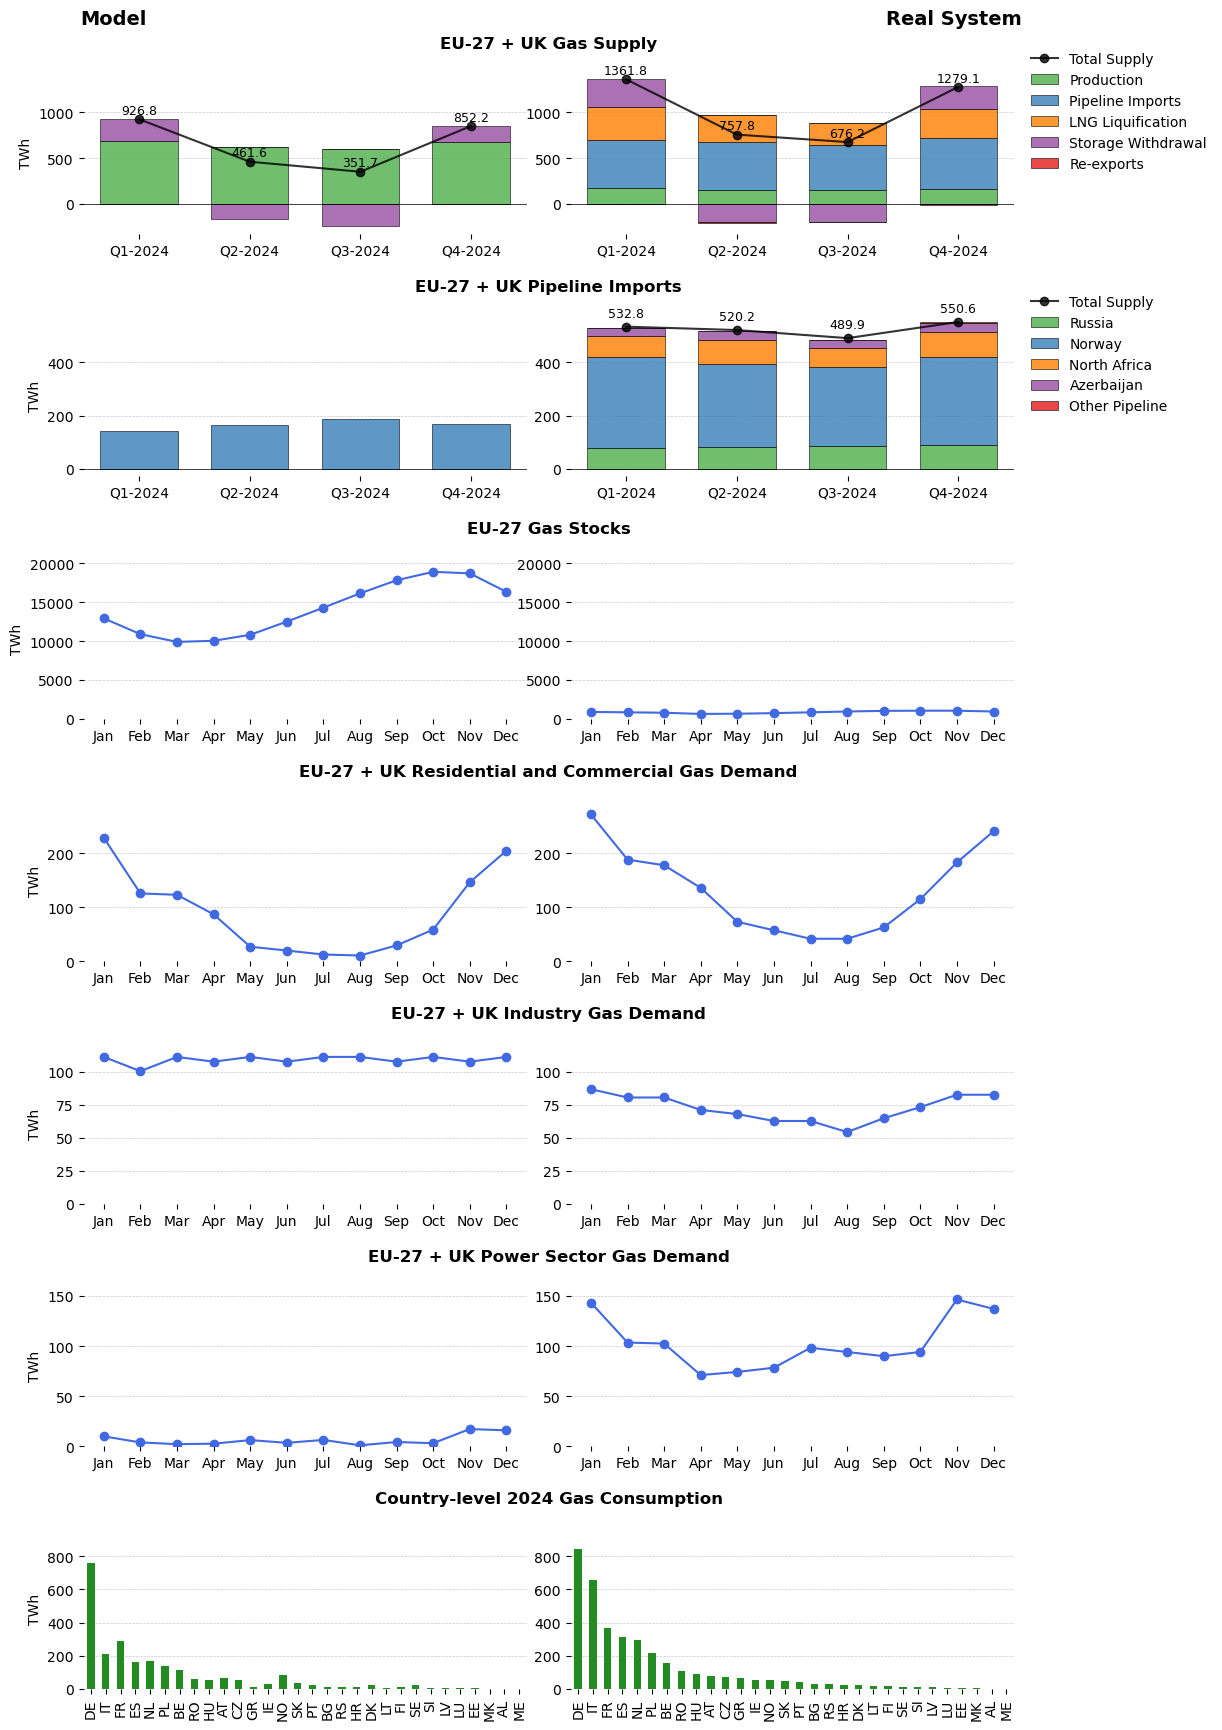

In [ ]:
nrows = 7

fig_height = 3 * nrows  # 3 inches per row
fig_width = 12      # 2*2*3 = 12 inches for 2:1 aspect per ax, 2 axes per row
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=2,
    figsize=(fig_width, fig_height),
    gridspec_kw={'wspace':0.1, 'hspace':0.5}
    )

row_fns = [
    plot_total_gas_supply,
    plot_pipeline_imports,
    plot_eu_gas_stock,
    plot_residential_commercial_demand,
    plot_industry_demand,
    plot_power_demand,
    plot_country_consumption,
]

right_data_list = [
    df_total_supply,
    df_pipeline_imports,
    df_storage_2024,
    df_2024_residential,
    df_2024_industrial,
    df_2024_power,
    ccon,
]

for i in range(7):
    model_ax = axes[i, 0]
    true_ax = axes[i, 1]
    row_fns[i](model_ax, true_ax, n, right_data_list[i], fig, i)

    model_ax.set_xlabel("")
    model_ax.set_ylabel("")
    true_ax.set_xlabel("")
    true_ax.set_ylabel("")

    fig.canvas.draw()  # Needed to ensure positions are up to date
    bbox1 = model_ax.get_position()
    bbox2 = true_ax.get_position()

    x0 = bbox1.x1 - 0.02 * (bbox2.x0 - bbox1.x1)  # slight overlap
    width = bbox2.x0 - bbox1.x1 + 0.04 * (bbox2.x0 - bbox1.x1)
    y0 = bbox1.y0
    height = bbox1.height

    bbox_top = model_ax.get_position()
    bbox_bottom = model_ax.get_position()
    y0 = bbox_bottom.y0
    height = (bbox_top.y1 - bbox_bottom.y0) / 5

    '''
    rect = patches.FancyBboxPatch(
        (x0, y0), width, height,
        boxstyle="round,pad=0.02",
        linewidth=1, edgecolor='gray', facecolor='white', alpha=0.95,
        transform=fig.transFigure, zorder=10
    )

    fig.patches.append(rect)

    fig.text(
        x0 + width/2, y0 + height/2,
        f"Legend/Explanation\nPlaceholder\n(Row {i+1})",
        ha='center', va='center', fontsize=10, color='black', zorder=11
    )
    '''

fig.text(0.15, 0.91, 'Model', ha='center', va='top', fontsize=14, fontweight='bold')
fig.text(0.85, 0.91, 'Real System', ha='center', va='top', fontsize=14, fontweight='bold')

for ax in axes[:,0]:
    ax.set_ylabel('TWh')

# plt.savefig('validation_starting_point.pdf', bbox_inches='tight')
plt.show()

In [164]:
ss = n.statistics.energy_balance(groupby=['carrier', 'bus'])

ss.loc[
    (ss.index.get_level_values(2).str.contains('gas')) &
    (ss.index.get_level_values(2).str.contains('NO')) &
    (ss.index.get_level_values(1) == 'gas pipeline')
]

component  carrier       bus      
Link       gas pipeline  NO1 0 gas   -662.71861
dtype: float64

In [100]:
pipes = n.links.index[n.links.carrier == 'gas pipeline']

In [27]:
def get_link_data(c):
    l = n.links.index[n.links.carrier == c]

    cols = ['marginal_cost', 'efficiency', 'capital_cost', 'p_nom', 'p_nom_opt']
    print(n.links.loc[[l[0]], cols])

In [28]:
get_link_data('OCGT')

                 marginal_cost  efficiency  capital_cost  p_nom  p_nom_opt
Link                                                                      
AL0 0 OCGT-2025       1.937854       0.405  19739.577493    0.0   0.024545


In [29]:
get_link_data('CCGT')

                 marginal_cost  efficiency  capital_cost  p_nom  p_nom_opt
Link                                                                      
AL0 0 CCGT-2025       2.603971        0.57   61475.63654    0.0   0.009458


In [30]:
get_link_data('coal')

                 marginal_cost  efficiency   capital_cost        p_nom  \
Link                                                                     
DE0 2 coal-1950       1.170296       0.356  120046.057771  2134.831461   

                   p_nom_opt  
Link                          
DE0 2 coal-1950  2134.831461  


In [37]:
ss = n.links.loc[n.links.carrier.isin(['OCGT', 'CCGT', 'coal', 'lignite'])]
ss.groupby('carrier')[['p_nom', 'p_nom_opt']].sum() / 1e3

,p_nom,p_nom_opt
carrier,,
CCGT,320.815959,332.948561
OCGT,0.057556,0.058830
coal,137.859267,137.859267
lignite,157.953647,157.953647


In [36]:
n.generators.loc[n.generators.carrier.isin(['gas', 'coal', 'lignite']), ['marginal_cost', 'capital_cost', 'carrier']].groupby('carrier').mean()

,marginal_cost,capital_cost
carrier,,
coal,9.564171,0.0
gas,24.578086,0.0
lignite,3.308927,0.0


In [40]:
prices = pd.read_csv(
    Path.cwd().parent / 'data' / 'TERMINAL - PA historical - 2025-10-21.csv', index_col=0, parse_dates=True
)

<Axes: xlabel='DATE'>

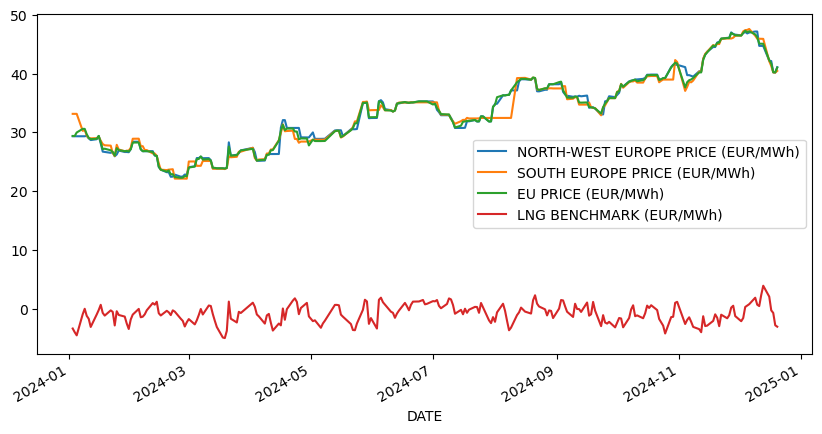

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
prices.loc['2024'].plot(ax=ax)


In [72]:
wbprices = pd.read_excel(
    Path.cwd().parent / 'data' / 'CMO-Historical-Data-Monthly.xlsx', sheet_name='Monthly Prices', header=[4,5,6], index_col=0, parse_dates=True,
)
wbprices = wbprices.loc[wbprices.index.str.contains('2024')]

gas_keepers = ['Natural gas, Europe', 'Liquefied natural gas, Japan']
coal_keepers = ['Coal, Australian', 'Coal, South African **']

wbprices = wbprices.loc[:, gas_keepers + coal_keepers]
wbprices.index = list(map(lambda x: f'{x[:4]}-{x[-2:]}', wbprices.index))

wbprices.columns = wbprices.columns.get_level_values(0)

wbprices.loc[:, gas_keepers] *= 3.152 # conversion from $/MMBtu to EUR/MWh

wbprices.loc[:, 'Coal, Australian'] *= 0.1325 # conversion from $/tonne to EUR/MWh (given caloric value read from Description sheet, 6000kcal/kg)
wbprices.loc[:, 'Coal, South African **'] *= 0.1325 # conversion from $/tonne to EUR/MWh (given caloric value read from Description sheet, 6000kcal/kg)

/tmp/ipykernel_1444421/1186659720.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wbprices = pd.read_excel(


<Axes: >

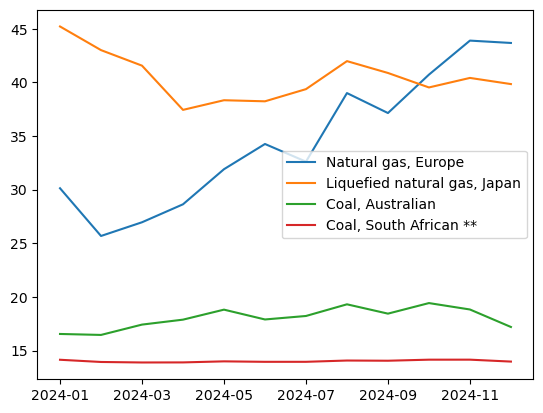

In [74]:
wbprices.plot()

In [61]:
wbprices.columns.get_level_values(0).unique()

Index(['Crude oil, average', 'Crude oil, Brent', 'Crude oil, Dubai',
       'Crude oil, WTI', 'Coal, Australian', 'Coal, South African **',
       'Natural gas, US', 'Natural gas, Europe',
       'Liquefied natural gas, Japan', 'Natural gas index', 'Cocoa',
       'Coffee, Arabica', 'Coffee, Robusta', 'Tea, avg 3 auctions',
       'Tea, Colombo', 'Tea, Kolkata', 'Tea, Mombasa', 'Coconut oil',
       'Groundnuts', 'Fish meal', 'Groundnut oil **', 'Palm oil',
       'Palm kernel oil', 'Soybeans', 'Soybean oil', 'Soybean meal',
       'Rapeseed oil', 'Sunflower oil', 'Barley', 'Maize', 'Sorghum',
       'Rice, Thai 5% ', 'Rice, Thai 25% ', 'Rice, Thai A.1',
       'Rice, Viet Namese 5%', 'Wheat, US SRW', 'Wheat, US HRW',
       'Banana, Europe', 'Banana, US', 'Orange', 'Beef **', 'Chicken **',
       'Lamb **', 'Shrimps, Mexican', 'Sugar, EU', 'Sugar, US', 'Sugar, world',
       'Tobacco, US import u.v.', 'Logs, Cameroon', 'Logs, Malaysian',
       'Sawnwood, Cameroon', 'Sawnwood, Malaysi